# 03e — Area of applicability (AOA) of the step-2 and diagnostic-3 models

The **area of applicability** (Meyer & Pebesma 2021, *Methods in Ecology and
Evolution* 12: 1620–1633, doi:10.1111/2041-210X.13650) is the part of the
predictor space in which a model can be expected to have the cross-validated
accuracy, because new points are not more dissimilar from the training data
than the training points are from each other. This notebook ports the R package
**CAST** (`trainDI()`, `aoa()`; source read at
github.com/HannaMeyer/CAST, commit `779e13f`, files `R/trainDI.R`, `R/aoa.R`,
`R/aoa-helpers.R`, `R/caret-helpers.R`) to Python.

**Method, as in the CAST source**

1. *Categorical predictors* (`.prepare_categorical_variables`,
   `.create_dummy_variables`): every factor is replaced by one 0/1 dummy per
   level **present in the training data** (`droplevels`, `caret::dummyVars`, full
   rank = no). A new point with a level not seen in training gets 0 on every
   dummy of that variable. Each dummy receives the **full weight** of its
   variable (`rep(weight, ncol(dummies))`), not a share of it. Land cover and
   biome are integer-coded in our data, so they are declared categorical here.
2. *Scaling*: `scale()` of the (dummy-expanded) training matrix: training mean
   and sample sd (n − 1); new data are scaled with the same parameters.
3. *Weights* (`.caret_get_weights`): `caret::varImp(model, scale = FALSE)`;
   for a classification random forest, caret's `rf` module returns the per-class
   columns of `randomForest::importance()` (permutation mean decrease in accuracy
   when the forest is grown with `importance = TRUE`) and CAST averages them over
   the classes. Negative weights are set to 0 (`.check_weights`). Our forests are
   sklearn forests without OOB permutation importance, so the weight is the
   permutation decrease in **balanced accuracy** (= mean over the two classes of
   the per-class accuracy decrease) on a balanced hold-out drawn from the
   training pool outside the training draw (as in step 3(c)), 5 repeats.
4. *Training DI* (`.calc_dist`, `.mask_dist_mat`): for each training point,
   the Euclidean distance (scaled, weighted space) to the nearest training point
   in the **training part of the CV fold in which the point is held out**; the
   mean distance of each training point to all other training points (no fold
   masking); DI = nearest distance / mean of those mean distances.
5. *Threshold* (`.di_threshold`): Q3 + 1.5 × IQR of the training DI (R `quantile`
   type 7 = numpy `linear`), capped at the maximum training DI.
6. *New data* (`aoa.data.frame`): DI = distance to the nearest of **all**
   training points / the same mean distance; inside the AOA if DI ≤ threshold
   (`AOA = ifelse(DI > threshold, 0, 1)`). Points with a missing predictor get no
   DI.

**Folds.** CAST takes the folds of the model's cross-validation and recommends
spatial folds when the model is evaluated with spatial CV. Our models were not
fitted by CV, so the folds are defined here: 5-fold `GroupKFold` by HEALPix cell
(NESTED, WGS84, `healpix_geo`) at **depth 6** (~100 km, used in both step 3(b)
and diagnostic 3) on each model's own training draw. Sensitivity thresholds:
HEALPix depth 7, random 5-fold, and no CV (`useCV = FALSE`: nearest other
training point). The DI of new points does not depend on the folds; only the
threshold does.

**Models** (refitted exactly as in `03_analysis` and `03d_transfer_test`: same
draws, seed and settings): the step-2 Colombia model, and the diagnostic-3
Neotropical models without and with Colombia.

**Applied to**: the Colombian prediction grid (1-in-100 systematic 30 m grid of
`02b`, 2018/2015 inputs, exact WGS84 pixel area × 100), the Colombian validation
points (2000 inputs; 2018 inputs for the non-regrowth comparison with the
authors' map) and, for the DI–accuracy relationship, the cross-validated
predictions on each model's training draw with the same HEALPix folds.

**The authors' map.** We do not have the authors' training data, so **this
notebook cannot compute the authors' AOA**. Section 5 only splits the authors'
published scores by **our** models' AOA.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from healpix_geo.nested import healpix_to_lonlat, lonlat_to_healpix, vertices
from matplotlib.collections import PolyCollection
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold, StratifiedKFold

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
SMOKE = os.environ.get("SMOKE", "0") == "1"
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
RESULTS = Path("../results/smoke" if SMOKE else "../results")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
for d in (RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)
N_TREES = 100 if SMOKE else 500
SEED = 20261003
MHA = 1e10
GRID_W = 100
FINAL_VARS = ["forest_density_2000", "dist_forest_2000", "ocdens", "phihox", "pc1", "pc2", "pc3", "pc4", "lc_2000", "biome"]
CAT_VARS = ["lc_2000", "biome"]
PRED_MAP = {"forest_density_2000": "forest_density_2018", "dist_forest_2000": "dist_forest_2018", "lc_2000": "lc_2015"}
VARS_2018 = [PRED_MAP.get(v, v) for v in FINAL_VARS]
COL_SHARE = 188_921 / 4_780_000
N_TRAIN = 2_000 if SMOKE else int(round(1_000_000 * COL_SHARE))
N_HOLDOUT = 1_000 if SMOKE else 10_000
FOLD_DEPTH = 6
N_FOLDS = 5
HP_DEPTH = 8
MODEL_LABELS = {"colombia": "Colombia (step 2)", "neotropics_excl_colombia": "Neotropics excl. Colombia",
                "neotropics_incl_colombia": "Neotropics incl. Colombia"}

samples = pd.read_parquet(CLEAN / "samples.parquet")
grid = pd.read_parquet(CLEAN / "pred_grid.parquet")
neo = pd.read_parquet(CLEAN / "neotropics_samples.parquet")
sums = pd.read_csv(CLEAN / "tile_sums.csv").drop(columns="tile").sum()
PI = float(sums["class1_area_ell"] / (sums["class1_area_ell"] + sums["class0_area_ell"]))
print(f"Colombian samples {len(samples):,}; Neotropical samples {len(neo):,}; grid {len(grid):,}; prevalence pi {PI:.5f}")


def make_rf(max_features: int = 3, seed: int = SEED) -> RandomForestClassifier:
    """Identical to 03_analysis.make_rf (R randomForest classification defaults)."""
    return RandomForestClassifier(n_estimators=N_TREES, max_features=max_features, min_samples_leaf=1, bootstrap=True,
                                  oob_score=True, n_jobs=-1, random_state=seed)


def balanced_train(pool: pd.DataFrame, n: int = N_TRAIN, seed: int = SEED) -> pd.DataFrame:
    return pd.concat([g.sample(n=min(n // 2, len(g)), random_state=seed) for _, g in pool.groupby("label")])


def prior_shift(p: np.ndarray, pi: float = PI, train_prev: float = 0.5) -> np.ndarray:
    num = p * pi / train_prev
    return num / (num + (1 - p) * (1 - pi) / (1 - train_prev))

Colombian samples 275,336; Neotropical samples 69,400; grid 12,161,726; prevalence pi 0.01644


## 1. Models and training draws (as in `03` and `03d`)

In [3]:
col_pool = samples[samples.set == "train_pool"]
col_val = samples[samples.set == "validation"].reset_index(drop=True)
val_key = set(zip(col_val.grow, col_val.gcol))
neo_pool = neo[(neo.set == "train_pool") & ~pd.Series(list(zip(neo.grow, neo.gcol)), index=neo.index).isin(val_key)]
TRAIN = {
    "colombia": pd.concat([g.sample(n=min(N_TRAIN // 2, len(g)), random_state=SEED) for _, g in col_pool.groupby("label")]),
    "neotropics_excl_colombia": balanced_train(neo_pool[~neo_pool.in_colombia]),
    "neotropics_incl_colombia": balanced_train(neo_pool),
}
HOLDOUT_POOL = {"colombia": col_pool, "neotropics_excl_colombia": neo_pool[~neo_pool.in_colombia],
                "neotropics_incl_colombia": neo_pool}
MODELS = {k: make_rf().fit(t[FINAL_VARS].to_numpy(), t.label.to_numpy()) for k, t in TRAIN.items()}
y_val = col_val.label.to_numpy()
P_VAL = {k: m.predict_proba(col_val[FINAL_VARS].to_numpy())[:, 1] for k, m in MODELS.items()}
for k in MODELS:
    print(f"{k:26s} n_train {len(TRAIN[k]):,}  Colombian validation accuracy {((P_VAL[k] > 0.5) == y_val).mean():.4f}")

colombia                   n_train 39,522  Colombian validation accuracy 0.8867
neotropics_excl_colombia   n_train 39,522  Colombian validation accuracy 0.7671
neotropics_incl_colombia   n_train 39,522  Colombian validation accuracy 0.7835


## 2. Variable weights (permutation importance, CAST / caret convention)

In [4]:
WEIGHTS = {}
for k, m in MODELS.items():
    rest = HOLDOUT_POOL[k].drop(TRAIN[k].index)
    if rest.label.nunique() < 2:  # smoke test only: the whole pool is in the training draw
        print(f"{k}: no hold-out records left, importance on the training draw")
        rest = TRAIN[k]
    ho = balanced_train(rest, N_HOLDOUT, SEED + 100)
    pi_ = permutation_importance(m, ho[FINAL_VARS].to_numpy(), ho.label.to_numpy(), scoring="balanced_accuracy",
                                 n_repeats=5, random_state=SEED, n_jobs=-1)
    WEIGHTS[k] = pd.Series(np.maximum(pi_.importances_mean, 0.0), index=FINAL_VARS)  # CAST: negative -> 0
weights = pd.DataFrame(WEIGHTS)
print(weights.round(4).to_string())

                     colombia  neotropics_excl_colombia  neotropics_incl_colombia
forest_density_2000    0.0619                    0.0586                    0.0602
dist_forest_2000       0.1607                    0.2527                    0.2559
ocdens                 0.0264                    0.0112                    0.0160
phihox                 0.0474                    0.0169                    0.0208
pc1                    0.0207                    0.0274                    0.0230
pc2                    0.0099                    0.0235                    0.0255
pc3                    0.0202                    0.0198                    0.0213
pc4                    0.0234                    0.0297                    0.0280
lc_2000                0.0077                    0.0145                    0.0145
biome                  0.0022                    0.0012                    0.0022


## 3. AOA functions (port of CAST `trainDI()` / `aoa()`)

In [5]:
class AOA:
    """CAST trainDI + aoa, Euclidean distance, categorical variables as full-weight dummies."""

    def __init__(self, train: pd.DataFrame, weight: pd.Series, folds: dict[str, np.ndarray]) -> None:
        self.levels = {v: np.sort(train[v].dropna().unique()) for v in CAT_VARS}
        X = self._expand(train[FINAL_VARS])
        w = np.concatenate([[weight[v]] for v in FINAL_VARS if v not in CAT_VARS]
                           + [np.full(len(self.levels[v]), weight[v]) for v in CAT_VARS])
        self.center = X.mean(axis=0)
        self.scale = X.std(axis=0, ddof=1)
        self.keep = self.scale > 0  # CAST stops on zero-variance columns; only possible in the smoke test
        if not self.keep.all():
            print("dropping zero-variance columns:", np.array(self.colnames)[~self.keep].tolist())
        self.w = w[self.keep]
        self.Xt = self._transform(X)
        self.tree = cKDTree(self.Xt)
        self.mean_dist = self._mean_pairwise()
        self.train_di = {name: self._cv_nearest(f) / self.mean_dist for name, f in folds.items()}
        self.thresholds = {name: di_threshold(di) for name, di in self.train_di.items()}

    def _expand(self, df: pd.DataFrame) -> np.ndarray:
        num = [v for v in FINAL_VARS if v not in CAT_VARS]
        cols = [df[v].to_numpy(dtype=float) for v in num]
        self.colnames = list(num)
        for v in CAT_VARS:
            x = df[v].to_numpy(dtype=float)
            for lev in self.levels[v]:
                cols.append((x == lev).astype(float))  # unseen level or NaN -> 0 on every dummy, as in CAST
                self.colnames.append(f"{v}_{lev:g}")
        return np.column_stack(cols)

    def _transform(self, X: np.ndarray) -> np.ndarray:
        return ((X - self.center) / np.where(self.scale > 0, self.scale, 1.0))[:, self.keep] * self.w

    def _mean_pairwise(self, batch: int = 2048) -> float:
        X = self.Xt
        n = len(X)
        sq = (X**2).sum(axis=1)
        row_mean = np.empty(n)
        for i in range(0, n, batch):
            q = X[i:i + batch]
            d = np.sqrt(np.maximum(sq[i:i + batch, None] - 2 * q @ X.T + sq[None, :], 0.0))
            d[np.arange(len(q)), np.arange(i, i + len(q))] = 0.0  # self-distance excluded
            row_mean[i:i + batch] = d.sum(axis=1) / (n - 1)
        return float(row_mean.mean())

    def _cv_nearest(self, fold: np.ndarray | None) -> np.ndarray:
        X = self.Xt
        out = np.empty(len(X))
        if fold is None:  # useCV = FALSE: nearest other training point (self masked by index only)
            d, idx = self.tree.query(X, k=2, workers=-1)
            self_first = idx[:, 0] == np.arange(len(X))
            return np.where(self_first, d[:, 1], d[:, 0])
        for f in np.unique(fold):
            te = fold == f
            out[te] = cKDTree(X[~te]).query(X[te], workers=-1)[0]
        return out

    def di(self, df: pd.DataFrame, batch: int = 500_000) -> np.ndarray:
        """DI of new data (columns named as FINAL_VARS); NaN where a predictor is missing."""
        out = np.full(len(df), np.nan)
        ok = ~df[FINAL_VARS].isna().any(axis=1).to_numpy()
        idx = np.flatnonzero(ok)
        for i in range(0, len(idx), batch):
            j = idx[i:i + batch]
            out[j] = self.tree.query(self._transform(self._expand(df.iloc[j])), workers=-1)[0] / self.mean_dist
        return out


def di_threshold(train_di: np.ndarray) -> float:
    """CAST .di_threshold: Q3 + 1.5 IQR, capped at the maximum training DI."""
    q1, q3 = np.nanquantile(train_di, [0.25, 0.75])
    return float(min(q3 + 1.5 * (q3 - q1), np.nanmax(train_di)))


def make_folds(t: pd.DataFrame) -> dict[str, np.ndarray | None]:
    y = t.label.to_numpy()
    out: dict[str, np.ndarray | None] = {}
    for depth in (FOLD_DEPTH, FOLD_DEPTH + 1):
        cells = lonlat_to_healpix(t.lon.to_numpy(), t.lat.to_numpy(), depth, ellipsoid="WGS84")
        k = min(N_FOLDS, len(np.unique(cells)))
        f = np.empty(len(t), dtype=int)
        for i, (_, te) in enumerate(GroupKFold(k).split(y, y, groups=cells)):
            f[te] = i
        out[f"healpix_d{depth}"] = f
    f = np.empty(len(t), dtype=int)
    for i, (_, te) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(y, y)):
        f[te] = i
    out["random_5fold"] = f
    out["none"] = None
    return out


PRIMARY = f"healpix_d{FOLD_DEPTH}"
FOLDS = {k: make_folds(t.reset_index(drop=True)) for k, t in TRAIN.items()}
AOAS = {k: AOA(TRAIN[k].reset_index(drop=True), WEIGHTS[k], FOLDS[k]) for k in MODELS}
for k, a in AOAS.items():
    di = a.train_di[PRIMARY]
    print(f"{k:26s} dims {a.Xt.shape[1]}  mean pairwise distance {a.mean_dist:.4f}  "
          f"training DI median {np.median(di):.4f}  thresholds "
          + ", ".join(f"{n} {t:.4f}" for n, t in a.thresholds.items()))

colombia                   dims 19  mean pairwise distance 0.1943  training DI median 0.0799  thresholds healpix_d6 0.1979, healpix_d7 0.1914, random_5fold 0.1792, none 0.1720
neotropics_excl_colombia   dims 22  mean pairwise distance 0.2006  training DI median 0.0619  thresholds healpix_d6 0.1630, healpix_d7 0.1454, random_5fold 0.1315, none 0.1249
neotropics_incl_colombia   dims 22  mean pairwise distance 0.2053  training DI median 0.0692  thresholds healpix_d6 0.1837, healpix_d7 0.1626, random_5fold 0.1483, none 0.1412


## 4. DI on the Colombian prediction grid and validation points

In [6]:
g = grid[grid.is_pred_domain].copy()
Xg = g[VARS_2018].rename(columns={v18: v for v, v18 in zip(FINAL_VARS, VARS_2018)})
ok = ~Xg.isna().any(axis=1).to_numpy()
area_incomplete = float((g.area_ell[~ok] * GRID_W).sum() / MHA)
g, Xg = g[ok].copy(), Xg[ok]
a_grid = g.area_ell.to_numpy() * GRID_W
auth_p = np.where(g.auth_pct.to_numpy() <= 100, g.auth_pct.to_numpy(), 0) / 100  # NoData = 0, as in 03d
print(f"grid points with complete predictors {len(g):,}; prediction-domain area without complete predictors "
      f"{area_incomplete:.4f} Mha (no DI, excluded)")

nr = col_val[col_val.label == 0].reset_index(drop=True)
nr18 = nr[VARS_2018].rename(columns={v18: v for v, v18 in zip(FINAL_VARS, VARS_2018)})
DI_GRID, DI_VAL, DI_NR18, P_GRID, P_NR18 = {}, {}, {}, {}, {}
for k, m in MODELS.items():
    DI_GRID[k] = AOAS[k].di(Xg)
    DI_VAL[k] = AOAS[k].di(col_val)
    DI_NR18[k] = AOAS[k].di(nr18)
    P_GRID[k] = m.predict_proba(Xg.to_numpy())[:, 1]
    P_NR18[k] = m.predict_proba(nr18.to_numpy())[:, 1]
    print(f"{k:26s} grid DI median {np.median(DI_GRID[k]):.4f}; share of grid area outside AOA "
          f"{(a_grid * (DI_GRID[k] > AOAS[k].thresholds[PRIMARY])).sum() / a_grid.sum():.4f}")

grid points with complete predictors 2,456,636; prediction-domain area without complete predictors 0.0915 Mha (no DI, excluded)


colombia                   grid DI median 0.0812; share of grid area outside AOA 0.0267


neotropics_excl_colombia   grid DI median 0.1382; share of grid area outside AOA 0.3174


neotropics_incl_colombia   grid DI median 0.1085; share of grid area outside AOA 0.1330


## 5. Summary: inside vs outside each model's AOA

Rows for every threshold variant (`cv_folds`); `healpix_d6` is the primary one.
`inside` / `outside` / `all` hold the metric on the respective subset. The
authors' rows split the **authors' published scores** by **our** model's AOA;
they are not the authors' AOA.

In [7]:
rows = []


def add(model: str, folds: str, metric: str, inside: float, outside: float, total: float, unit: str,
        note: str = "") -> None:
    rows.append(dict(model=model, cv_folds=folds, metric=metric, inside=inside, outside=outside, all=total,
                     unit=unit, note=note))


def split_sum(x: np.ndarray, inside: np.ndarray, scale: float = MHA) -> tuple[float, float, float]:
    return float(x[inside].sum() / scale), float(x[~inside].sum() / scale), float(x.sum() / scale)


def class_acc(correct: np.ndarray, y: np.ndarray) -> dict[str, float]:
    a1 = float(correct[y == 1].mean()) if (y == 1).any() else np.nan
    a0 = float(correct[y == 0].mean()) if (y == 0).any() else np.nan
    return {"accuracy": float(correct.mean()) if len(y) else np.nan, "accuracy_regrowth": a1,
            "accuracy_nonregrowth": a0, "balanced_accuracy": np.nanmean([a1, a0]) if len(y) else np.nan}


def split_mean(x: np.ndarray, inside: np.ndarray) -> tuple[float, float, float]:
    f = lambda s: float(x[s].mean()) if s.any() else np.nan  # noqa: E731
    return f(inside), f(~inside), float(x.mean())


nr_auth_ok = (nr.auth_pct <= 100).to_numpy()
nr_auth = nr.auth_pct.to_numpy() / 100
DI_NR00 = {k: DI_VAL[k][(col_val.label == 0).to_numpy()] for k in MODELS}
for k, a in AOAS.items():
    for folds, thr in a.thresholds.items():
        tdi = a.train_di[folds]
        q1, q3 = np.quantile(tdi, [0.25, 0.75])
        add(k, folds, "threshold", np.nan, np.nan, thr, "DI", "CAST: min(Q3 + 1.5 IQR, max) of the CV training DI")
        add(k, folds, "train_di_median", np.nan, np.nan, float(np.median(tdi)), "DI")
        add(k, folds, "train_di_q3", np.nan, np.nan, float(q3), "DI")
        add(k, folds, "train_di_iqr", np.nan, np.nan, float(q3 - q1), "DI")
        add(k, folds, "train_di_max", np.nan, np.nan, float(tdi.max()), "DI")
        add(k, folds, "share_training_outside", np.nan, np.nan, float((tdi > thr).mean()), "fraction")
        add(k, folds, "mean_pairwise_distance", np.nan, np.nan, a.mean_dist, "scaled weighted units")
        ins = DI_GRID[k] <= thr
        add(k, folds, "pred_domain_area_mha", *split_sum(a_grid, ins), "Mha",
            f"exact WGS84 area of 1-in-100 grid points x 100; {area_incomplete:.4f} Mha without complete predictors "
            "excluded")
        i_, o_, t_ = split_sum(a_grid, ins, 1.0)
        add(k, folds, "pred_domain_area_share", i_ / t_, o_ / t_, 1.0, "fraction")
        add(k, folds, "expected_area_uncal_mha", *split_sum(P_GRID[k] * a_grid, ins), "Mha", "sum p x area (paper)")
        add(k, folds, "expected_area_prior_shift_mha", *split_sum(prior_shift(P_GRID[k]) * a_grid, ins), "Mha",
            f"prior-shift to Colombian prevalence {PI:.5f}")
        add(k, folds, "area_p_gt05_uncal_mha", *split_sum((P_GRID[k] > 0.5) * a_grid, ins), "Mha")
        add(k, folds, "mean_p_grid_area_weighted",
            *(s / w for s, w in zip(split_sum(P_GRID[k] * a_grid, ins, 1.0), split_sum(a_grid, ins, 1.0))), "p")
        add(k, folds, "authors_expected_area_mha", *split_sum(auth_p * a_grid, ins), "Mha",
            "authors' published map split by OUR model's AOA (not the authors' AOA); NoData = 0")
        add(k, folds, "authors_area_pct_gt50_mha", *split_sum((auth_p > 0.5) * a_grid, ins), "Mha",
            "authors' map split by OUR model's AOA")
        iv = DI_VAL[k] <= thr
        corr = (P_VAL[k] > 0.5) == y_val
        add(k, folds, "validation_accuracy_2000", *split_mean(corr.astype(float), iv), "fraction",
            "Colombian validation points, 2000 inputs; class mix differs inside/outside, see balanced accuracy")
        for key in ["accuracy_regrowth", "accuracy_nonregrowth", "balanced_accuracy"]:
            add(k, folds, f"validation_{key}_2000", class_acc(corr[iv], y_val[iv])[key],
                class_acc(corr[~iv], y_val[~iv])[key], class_acc(corr, y_val)[key], "fraction",
                "Colombian validation points, 2000 inputs")
        add(k, folds, "validation_n", float(iv.sum()), float((~iv).sum()), float(len(iv)), "points")
        add(k, folds, "validation_share_regrowth", *split_mean(y_val.astype(float), iv), "fraction")
        for yr, di_nr, p_nr in [("2000", DI_NR00[k], P_VAL[k][y_val == 0]), ("2018", DI_NR18[k], P_NR18[k])]:
            inr = di_nr <= thr
            add(k, folds, f"nonregrowth_n_{yr}", float(inr.sum()), float((~inr).sum()), float(len(inr)), "points",
                f"Colombian non-regrowth validation points, AOA from {yr} inputs")
            add(k, folds, f"nonregrowth_mean_p_model_{yr}", *split_mean(p_nr, inr), "p", f"{yr} inputs")
            add(k, folds, f"nonregrowth_share_gt05_model_{yr}", *split_mean((p_nr > 0.5).astype(float), inr),
                "fraction", f"{yr} inputs")
            ia = inr[nr_auth_ok]
            add(k, folds, f"nonregrowth_mean_p_authors_aoa{yr}", *split_mean(nr_auth[nr_auth_ok], ia), "p",
                f"authors' score (pct/100, NoData excluded) split by OUR AOA from {yr} inputs; not the authors' AOA")
            add(k, folds, f"nonregrowth_share_gt05_authors_aoa{yr}",
                *split_mean((nr_auth[nr_auth_ok] > 0.5).astype(float), ia), "fraction",
                f"authors' score split by OUR AOA from {yr} inputs; not the authors' AOA")
summary = pd.DataFrame(rows)
summary.to_csv(RESULTS / "aoa_summary.csv", index=False)
with pd.option_context("display.width", 250, "display.max_rows", 500, "display.max_colwidth", 40):
    print(summary[summary.cv_folds == PRIMARY].drop(columns=["cv_folds", "note"])
          .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                   model                                 metric      inside    outside         all                  unit
                colombia                              threshold         NaN        NaN      0.1979                    DI
                colombia                        train_di_median         NaN        NaN      0.0799                    DI
                colombia                            train_di_q3         NaN        NaN      0.1116                    DI
                colombia                           train_di_iqr         NaN        NaN      0.0575                    DI
                colombia                           train_di_max         NaN        NaN      3.2022                    DI
                colombia                 share_training_outside         NaN        NaN      0.0302              fraction
                colombia                 mean_pairwise_distance         NaN        NaN      0.1943 scaled weighted units
                colombia        

## 6. DI and accuracy (Meyer & Pebesma 2021)

Accuracy by DI decile for (i) the Colombian validation points under each model
(for the Neotropical models these are the diagnostic-3 transfer points) and
(ii) cross-validated predictions on each model's training draw with the primary
HEALPix folds: each fold model is fitted on the other folds (same settings), and
the DI of a held-out point is its CAST training DI.

The class mix changes strongly with DI (regrowth points are close to forest and
to each other in predictor space; high-DI points are mostly non-regrowth), so
plain accuracy by DI mixes a class effect with a dissimilarity effect. Accuracy
per class and balanced accuracy are reported alongside.

In [8]:
P_CV = {}
for k, t in TRAIN.items():
    t = t.reset_index(drop=True)
    X, y, f = t[FINAL_VARS].to_numpy(), t.label.to_numpy(), FOLDS[k][PRIMARY]
    p = np.empty(len(t))
    for i in np.unique(f):
        te = f == i
        p[te] = make_rf(seed=SEED + int(i)).fit(X[~te], y[~te]).predict_proba(X[te])[:, 1]
    P_CV[k] = (p, y)
    print(f"{k:26s} CV ({PRIMARY}) accuracy {((p > 0.5) == y).mean():.4f}")

N_BINS = 5 if SMOKE else 10
bin_rows = []
SETS = {}
for k in MODELS:
    SETS[(k, "colombia_validation_2000")] = (DI_VAL[k], P_VAL[k], y_val)
    SETS[(k, f"cv_heldout_{PRIMARY}")] = (AOAS[k].train_di[PRIMARY], *P_CV[k])
for (k, pset), (di, p, y) in SETS.items():
    thr = AOAS[k].thresholds[PRIMARY]
    edges = np.unique(np.quantile(di, np.linspace(0, 1, N_BINS + 1)))
    b = np.clip(np.searchsorted(edges, di, side="right") - 1, 0, len(edges) - 2)
    for i in range(len(edges) - 1):
        s = b == i
        if s.any():
            bin_rows.append(dict(model=k, point_set=pset, bin=i, di_lo=edges[i], di_hi=edges[i + 1],
                                 di_mean=float(di[s].mean()), n=int(s.sum()),
                                 **class_acc((p[s] > 0.5) == y[s], y[s]), share_regrowth=float(y[s].mean()),
                                 share_outside_aoa=float((di[s] > thr).mean()), threshold=thr))
    ins = di <= thr
    for lab, s in [("inside_aoa", ins), ("outside_aoa", ~ins), ("all", np.ones_like(ins))]:
        if s.any():
            bin_rows.append(dict(model=k, point_set=pset, bin=lab, di_lo=float(di[s].min()), di_hi=float(di[s].max()),
                                 di_mean=float(di[s].mean()), n=int(s.sum()),
                                 **class_acc((p[s] > 0.5) == y[s], y[s]), share_regrowth=float(y[s].mean()),
                                 share_outside_aoa=float((~ins[s]).mean()), threshold=thr))
di_acc = pd.DataFrame(bin_rows)
di_acc.to_csv(RESULTS / "aoa_di_accuracy.csv", index=False)
with pd.option_context("display.width", 250, "display.max_rows", 200):
    print(di_acc.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

colombia                   CV (healpix_d6) accuracy 0.8561


neotropics_excl_colombia   CV (healpix_d6) accuracy 0.8344


neotropics_incl_colombia   CV (healpix_d6) accuracy 0.8285
                   model                point_set         bin  di_lo   di_hi  di_mean      n  accuracy  accuracy_regrowth  accuracy_nonregrowth  balanced_accuracy  share_regrowth  share_outside_aoa  threshold
                colombia colombia_validation_2000           0 0.0000  0.0212   0.0135  12336    0.9772             0.9931                0.5158             0.7545          0.9667             0.0000     0.1979
                colombia colombia_validation_2000           1 0.0212  0.0315   0.0263  12335    0.9245             0.9723                0.5948             0.7835          0.8734             0.0000     0.1979
                colombia colombia_validation_2000           2 0.0315  0.0421   0.0368  12336    0.8705             0.9170                0.7452             0.8311          0.7296             0.0000     0.1979
                colombia colombia_validation_2000           3 0.0421  0.0517   0.0469  12335    0.8469   

## 7. HEALPix depth-8 share of the prediction domain outside the AOA (WGS84)

In [9]:
g["cell"] = lonlat_to_healpix(g.lon.to_numpy(), g.lat.to_numpy(), HP_DEPTH, ellipsoid="WGS84")
cols = {"pred_area": a_grid}
for k in MODELS:
    cols[f"outside_area_{k}"] = a_grid * (DI_GRID[k] > AOAS[k].thresholds[PRIMARY])
    cols[f"di_x_area_{k}"] = a_grid * DI_GRID[k]
cells = pd.DataFrame(cols).groupby(g.cell.to_numpy()).sum()
cell_ids = cells.index.to_numpy().astype("uint64")
lon_c, lat_c = healpix_to_lonlat(cell_ids, HP_DEPTH, ellipsoid="WGS84")
data_vars = {"pred_area": ("cells", cells.pred_area.to_numpy(),
                           {"units": "m2", "long_name": "prediction-domain area with complete predictors"})}
for k in MODELS:
    data_vars[f"outside_area_{k}"] = ("cells", cells[f"outside_area_{k}"].to_numpy(),
                                      {"units": "m2", "long_name": f"area outside the AOA, {MODEL_LABELS[k]} model"})
    data_vars[f"share_outside_{k}"] = ("cells", (cells[f"outside_area_{k}"] / cells.pred_area).to_numpy(),
                                       {"units": "1", "long_name": f"share outside the AOA, {MODEL_LABELS[k]} model",
                                        "threshold": AOAS[k].thresholds[PRIMARY]})
    data_vars[f"mean_di_{k}"] = ("cells", (cells[f"di_x_area_{k}"] / cells.pred_area).to_numpy(),
                                 {"units": "1", "long_name": f"area-weighted mean DI, {MODEL_LABELS[k]} model"})
ds = xr.Dataset(data_vars,
                coords={"cell_ids": ("cells", cell_ids, {"grid_name": "healpix", "level": HP_DEPTH,
                                                         "indexing_scheme": "nested", "ellipsoid": "WGS84"}),
                        "longitude": ("cells", (np.asarray(lon_c) + 180) % 360 - 180),
                        "latitude": ("cells", np.asarray(lat_c))},
                attrs={"title": "Area of applicability (Meyer & Pebesma 2021, CAST port) of the step-2 and diagnostic-3 "
                                "models over the Colombian prediction domain, HEALPix depth 8",
                       "method": f"1-in-100 systematic 30 m grid, 2018/2015 inputs; exact WGS84 pixel area x 100; "
                                 f"threshold from CV training DI with HEALPix depth-{FOLD_DEPTH} folds"})
ds.to_netcdf(RESULTS / "aoa_healpix_d8.nc")
print(ds)

<xarray.Dataset> Size: 170kB
Dimensions:                                 (cells: 1635)
Coordinates:
    cell_ids                                (cells) uint64 13kB 478916 ... 51...
    longitude                               (cells) float64 13kB -69.96 ... -...
    latitude                                (cells) float64 13kB -4.351 ... 1...
Dimensions without coordinates: cells
Data variables:
    pred_area                               (cells) float64 13kB 6.138e+05 .....
    outside_area_colombia                   (cells) float64 13kB 3.836e+05 .....
    share_outside_colombia                  (cells) float64 13kB 0.625 ... 0....
    mean_di_colombia                        (cells) float64 13kB 0.2431 ... 0...
    outside_area_neotropics_excl_colombia   (cells) float64 13kB 7.673e+04 .....
    share_outside_neotropics_excl_colombia  (cells) float64 13kB 0.125 ... 0.0
    mean_di_neotropics_excl_colombia        (cells) float64 13kB 0.1216 ... 0...
    outside_area_neotropics_incl_colom

## 8. Figure

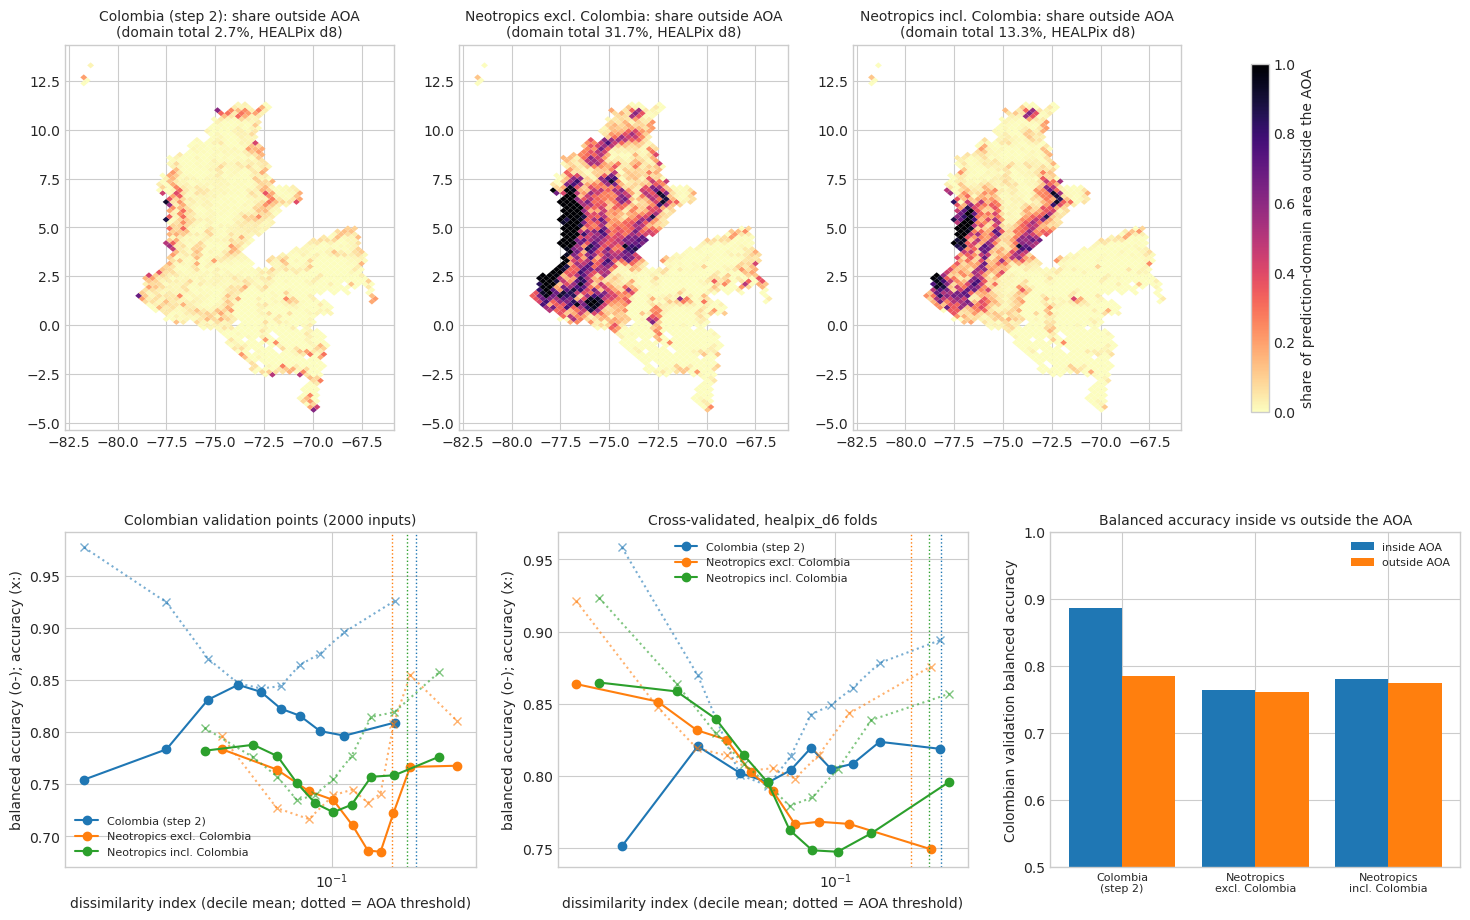

In [10]:
def cell_polys(ids: np.ndarray) -> list[np.ndarray]:
    lo, la = vertices(ids.astype("uint64"), HP_DEPTH, ellipsoid="WGS84")
    lo = (np.asarray(lo) + 180) % 360 - 180
    return [np.column_stack([a, b]) for a, b in zip(lo, np.asarray(la))]


polys = cell_polys(cell_ids)
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1])
for i, k in enumerate(MODELS):
    ax = fig.add_subplot(gs[0, i])
    pc = PolyCollection(polys, array=ds[f"share_outside_{k}"].to_numpy(), cmap="magma_r", edgecolor="none")
    pc.set_clim(0, 1)
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect("equal")
    share = summary.query("model == @k and cv_folds == @PRIMARY and metric == 'pred_domain_area_share'").outside.iloc[0]
    ax.set_title(f"{MODEL_LABELS[k]}: share outside AOA\n(domain total {share:.1%}, HEALPix d8)", fontsize=10)
fig.colorbar(pc, ax=fig.axes[:3], shrink=0.8, label="share of prediction-domain area outside the AOA")
for j, pset in enumerate(["colombia_validation_2000", f"cv_heldout_{PRIMARY}"]):
    ax = fig.add_subplot(gs[1, j])
    for i, k in enumerate(MODELS):
        d = di_acc[(di_acc.model == k) & (di_acc.point_set == pset) & ~di_acc.bin.isin(["inside_aoa", "outside_aoa", "all"])]
        ax.plot(d.di_mean, d.balanced_accuracy, "o-", color=f"C{i}", label=MODEL_LABELS[k])
        ax.plot(d.di_mean, d.accuracy, "x:", color=f"C{i}", alpha=0.6)
        ax.axvline(AOAS[k].thresholds[PRIMARY], color=f"C{i}", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("dissimilarity index (decile mean; dotted = AOA threshold)")
    ax.set_ylabel("balanced accuracy (o-); accuracy (x:)")
    ax.set_title("Colombian validation points (2000 inputs)" if j == 0 else f"Cross-validated, {PRIMARY} folds",
                 fontsize=10)
    ax.legend(fontsize=8)
ax = fig.add_subplot(gs[1, 2])
sub = summary[(summary.cv_folds == PRIMARY) & (summary.metric == "validation_balanced_accuracy_2000")].set_index("model")
x = np.arange(len(sub))
ax.bar(x - 0.2, sub.inside, 0.4, label="inside AOA")
ax.bar(x + 0.2, sub.outside, 0.4, label="outside AOA")
ax.set_xticks(x, [MODEL_LABELS[k].replace(" ", "\n", 1) for k in sub.index], fontsize=8)
ax.set_ylim(0.5, 1)
ax.set_ylabel("Colombian validation balanced accuracy")
ax.set_title("Balanced accuracy inside vs outside the AOA", fontsize=10)
ax.legend(fontsize=8)
fig.savefig(FIGURES / "aoa_colombia.png", dpi=150, bbox_inches="tight")
plt.show()